### 1. Data Loading & Exploration


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split,GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
import warnings 
warnings.filterwarnings('ignore')

# set style for better plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Cell 2: Load Dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

print("="*60)
print("DATASET INFORMATION")
print("="*60)
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"Features: {list(X.columns[:5])} ... (showing first 5)")
print(f"\nTarget distribution:")
print(y.value_counts())
print(f"\nDataset preview:")
print(X.head())

DATASET INFORMATION
Number of samples: 569
Number of features: 30
Features: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness'] ... (showing first 5)

Target distribution:
target
1    357
0    212
Name: count, dtype: int64

Dataset preview:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974            

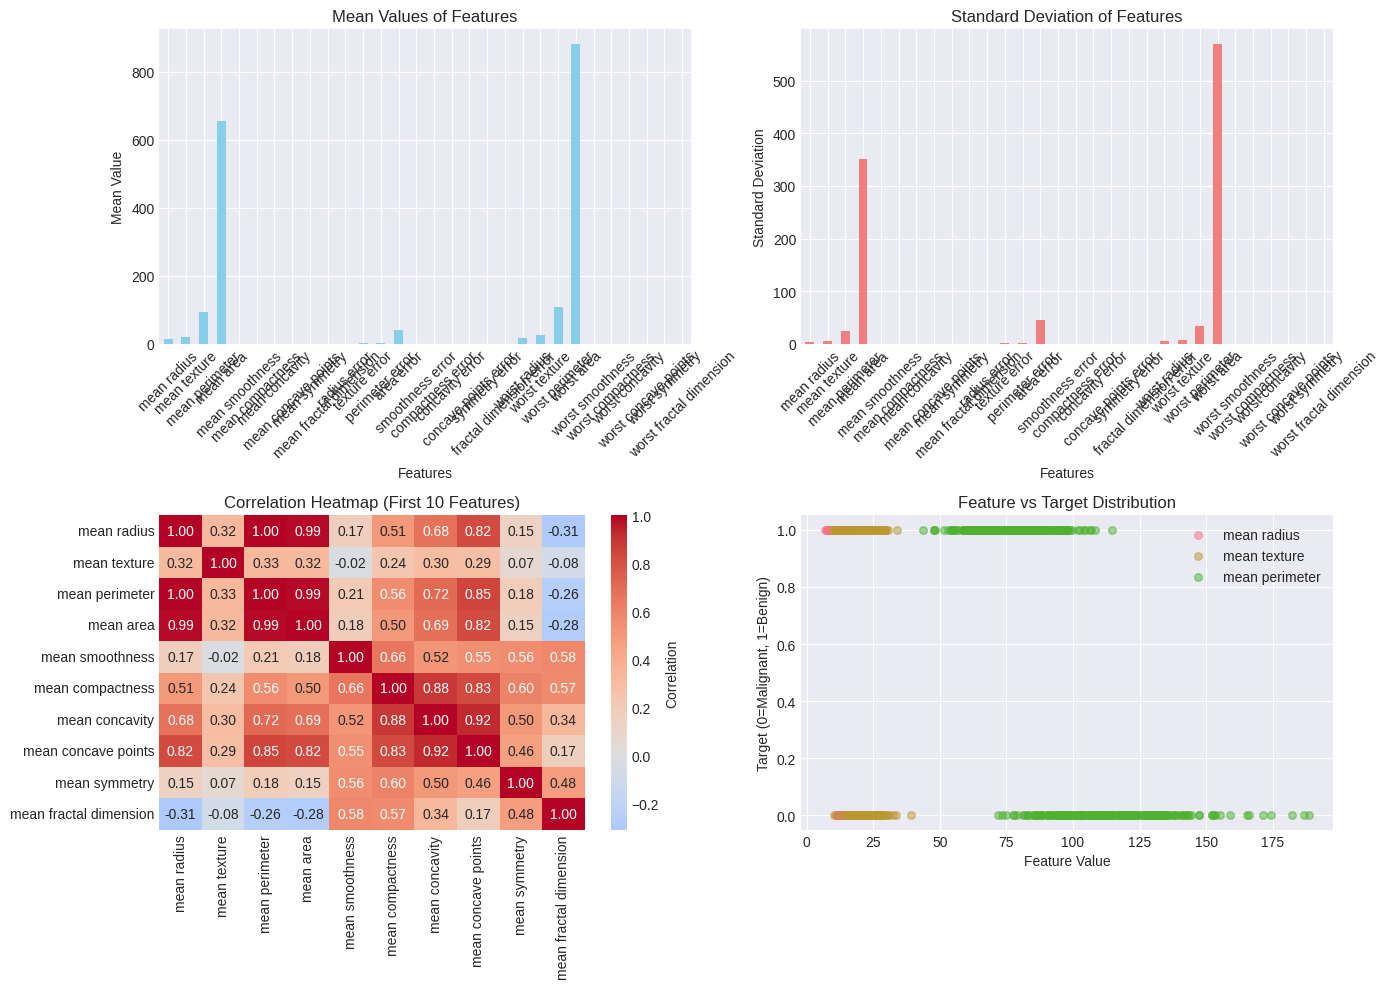

In [3]:
# Cell 3: Exploratory Data Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Feature distributions
ax = axes[0, 0]
X.mean().plot(kind='bar', ax=ax, color='skyblue')
ax.set_title('Mean Values of Features')
ax.set_xlabel('Features')
ax.set_ylabel('Mean Value')
ax.tick_params(axis='x', rotation=45)

# 2. Feature standard deviations
ax = axes[0, 1]
X.std().plot(kind='bar', ax=ax, color='lightcoral')
ax.set_title('Standard Deviation of Features')
ax.set_xlabel('Features')
ax.set_ylabel('Standard Deviation')
ax.tick_params(axis='x', rotation=45)

# 3. Correlation heatmap (first 10 features)
ax = axes[1, 0]
corr_matrix = X.iloc[:, :10].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, ax=ax, cbar_kws={'label': 'Correlation'})
ax.set_title('Correlation Heatmap (First 10 Features)')

# 4. Target distribution by feature
ax = axes[1, 1]
for feature in ['mean radius', 'mean texture', 'mean perimeter']:
    ax.scatter(X[feature], y, alpha=0.5, label=feature, s=30)
ax.set_xlabel('Feature Value')
ax.set_ylabel('Target (0=Malignant, 1=Benign)')
ax.set_title('Feature vs Target Distribution')
ax.legend()

plt.tight_layout()
plt.show()

### Data preprocessing


In [4]:
# Cell 4: train-test split
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size = 0.2,random_state=42
) 

print("="*60)
print("DATA SPLIT")
print("="*60)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTraining target distribution:")
print(y_train.value_counts())
print(f"\nTest target distribution:")
print(y_test.value_counts())


DATA SPLIT
Training set: 455 samples
Test set: 114 samples

Training target distribution:
target
1    286
0    169
Name: count, dtype: int64

Test target distribution:
target
1    71
0    43
Name: count, dtype: int64


In [5]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier interpretation
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

print("="*60)
print("FEATURE SCALING COMPLETE")
print("="*60)
print(f"Training set shape (scaled): {X_train_scaled.shape}")
print(f"Test set shape (scaled): {X_test_scaled.shape}")
print(f"\nScaled feature statistics (first 5 features):")
print(X_train_scaled_df.iloc[:, :5].describe())

FEATURE SCALING COMPLETE
Training set shape (scaled): (455, 30)
Test set shape (scaled): (114, 30)

Scaled feature statistics (first 5 features):
        mean radius  mean texture  mean perimeter     mean area  \
count  4.550000e+02  4.550000e+02    4.550000e+02  4.550000e+02   
mean  -3.162306e-16 -3.513673e-17   -1.132183e-16  3.669836e-16   
std    1.001101e+00  1.001101e+00    1.001101e+00  1.001101e+00   
min   -1.819583e+00 -2.223500e+00   -1.809497e+00 -1.365036e+00   
25%   -6.830930e-01 -7.075360e-01   -6.907613e-01 -6.602049e-01   
50%   -2.314983e-01 -1.185158e-01   -2.429378e-01 -2.895973e-01   
75%    4.593426e-01  5.631988e-01    4.884799e-01  3.193386e-01   
max    3.961679e+00  4.715674e+00    3.976811e+00  5.208312e+00   

       mean smoothness  
count     4.550000e+02  
mean     -2.381489e-16  
std       1.001101e+00  
min      -3.100011e+00  
25%      -7.132037e-01  
50%      -8.082013e-02  
75%       6.331729e-01  
max       4.864642e+00  


### Model Training - Ridge Regression


In [10]:
# Cell 6: Ridge Regression with Cross-Validation
print("="*60)
print("RIDGE REGRESSION")
print("="*60)

#Create Ridge model with cross-validation
alphas = np.logspace(-4, 4, 50)
ridge_cv = Ridge(alpha=1.0)  # Start with default

# Find the best alpha using cross-validation
from sklearn.linear_model import RidgeCV
ridge_cv_model = RidgeCV(alphas = alphas, cv=5, scoring='r2')
ridge_cv_model.fit(X_train_scaled, y_train)

best_ridge_alpha = ridge_cv_model.alpha_
print(f"Best alpha (λ) from CV: {best_ridge_alpha:.4f}")

# Train final Ridge model
ridge = Ridge(alpha=best_ridge_alpha)
ridge.fit(X_train_scaled,y_train)

# Predictions
ridge_train_pred = ridge.predict(X_train_scaled)
ridge_test_pred = ridge.predict(X_test_scaled)

# Metrics
ridge_train_r2 = r2_score(y_train, ridge_train_pred)
ridge_test_r2 = r2_score(y_test, ridge_test_pred)
ridge_test_mse = mean_squared_error(y_test, ridge_test_pred)
ridge_test_rmse = np.sqrt(ridge_test_mse)
ridge_test_mae = mean_absolute_error(y_test, ridge_test_pred)

print(f"\nTraining R²: {ridge_train_r2:.4f}")
print(f"Test R²: {ridge_test_r2:.4f}")
print(f"Test MSE: {ridge_test_mse:.4f}")
print(f"Test RMSE: {ridge_test_rmse:.4f}")
print(f"Test MAE: {ridge_test_mae:.4f}")
print(f"\nNumber of zero coefficients: {np.sum(np.abs(ridge.coef_) < 1e-10)}")


RIDGE REGRESSION
Best alpha (λ) from CV: 1.7575

Training R²: 0.7753
Test R²: 0.7394
Test MSE: 0.0612
Test RMSE: 0.2474
Test MAE: 0.1957

Number of zero coefficients: 0


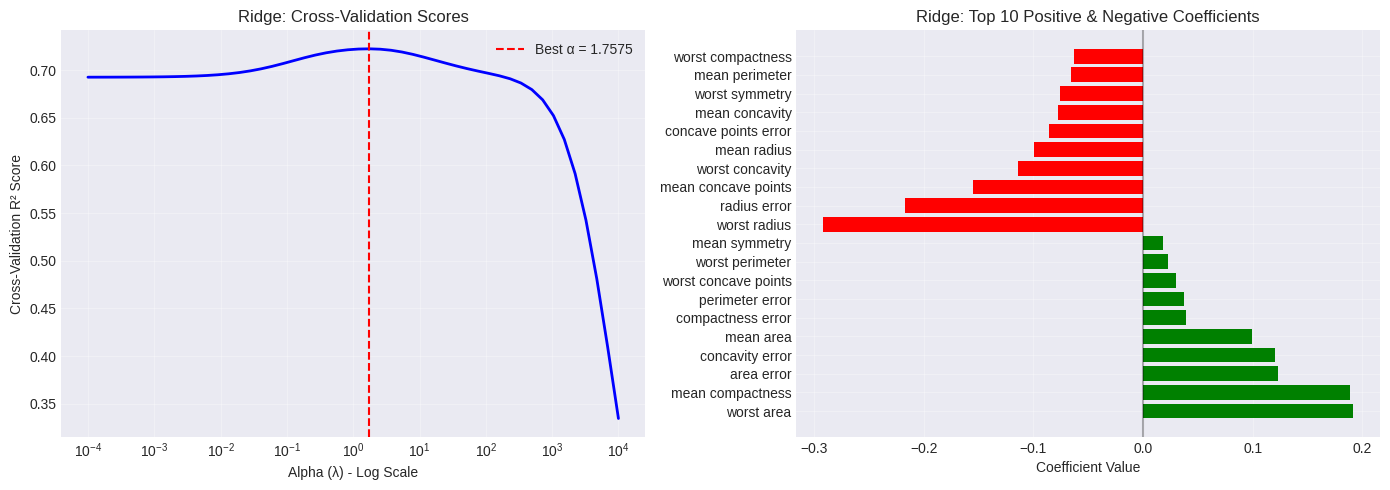

In [12]:
# Cell 7: Ridge Cross-Validation Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Ridge CV scores
ax = axes[0]
cv_scores = []
for alpha in alphas:
    ridge_temp = Ridge(alpha=alpha)
    scores = cross_val_score(ridge_temp, X_train_scaled, y_train, cv=5, scoring='r2')
    cv_scores.append(scores.mean())

ax.semilogx(alphas, cv_scores, 'b-', linewidth=2)
ax.axvline(best_ridge_alpha, color='red', linestyle='--', 
           label=f'Best α = {best_ridge_alpha:.4f}')
ax.set_xlabel('Alpha (λ) - Log Scale')
ax.set_ylabel('Cross-Validation R² Score')
ax.set_title('Ridge: Cross-Validation Scores')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Ridge coefficients
ax = axes[1]
coeffs_ridge = pd.DataFrame({
    'Feature': data.feature_names,
    'Coefficient': ridge.coef_
})
top_coeffs = coeffs_ridge.nlargest(10, 'Coefficient')
bottom_coeffs = coeffs_ridge.nsmallest(10, 'Coefficient')
top_bottom = pd.concat([top_coeffs, bottom_coeffs])

colors = ['green' if c > 0 else 'red' for c in top_bottom['Coefficient']]
ax.barh(top_bottom['Feature'], top_bottom['Coefficient'], color=colors)
ax.set_xlabel('Coefficient Value')
ax.set_title('Ridge: Top 10 Positive & Negative Coefficients')
ax.axvline(0, color='black', linestyle='-', alpha=0.3)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4. Model Training - Lasso(Baseline)

In [13]:
# Cell 8: Lasso Regression with Cross-Validation
print("="*60)
print("LASSO REGRESSION")
print("="*60)

from sklearn.linear_model import LassoCV

# Lasso with automatic cross-validation
lasso_cv_model = LassoCV(alphas=alphas, cv=5, random_state=42, max_iter=10000)
lasso_cv_model.fit(X_train_scaled, y_train)

best_lasso_alpha = lasso_cv_model.alpha_
print(f"Best alpha (λ) from CV: {best_lasso_alpha:.4f}")

# Train final Lasso model
lasso = Lasso(alpha=best_lasso_alpha, max_iter=10000)
lasso.fit(X_train_scaled, y_train)

# Predictions
lasso_train_pred = lasso.predict(X_train_scaled)
lasso_test_pred = lasso.predict(X_test_scaled)

# Metrics
lasso_train_r2 = r2_score(y_train, lasso_train_pred)
lasso_test_r2 = r2_score(y_test, lasso_test_pred)
lasso_test_mse = mean_squared_error(y_test, lasso_test_pred)
lasso_test_rmse = np.sqrt(lasso_test_mse)
lasso_test_mae = mean_absolute_error(y_test, lasso_test_pred)

print(f"\nTraining R²: {lasso_train_r2:.4f}")
print(f"Test R²: {lasso_test_r2:.4f}")
print(f"Test MSE: {lasso_test_mse:.4f}")
print(f"Test RMSE: {lasso_test_rmse:.4f}")
print(f"Test MAE: {lasso_test_mae:.4f}")
print(f"\nNumber of zero coefficients: {np.sum(np.abs(lasso.coef_) < 1e-10)}")
print(f"Features selected: {np.sum(np.abs(lasso.coef_) > 1e-10)} out of {len(lasso.coef_)}")

LASSO REGRESSION
Best alpha (λ) from CV: 0.0010

Training R²: 0.7747
Test R²: 0.7514
Test MSE: 0.0584
Test RMSE: 0.2416
Test MAE: 0.1918

Number of zero coefficients: 7
Features selected: 23 out of 30


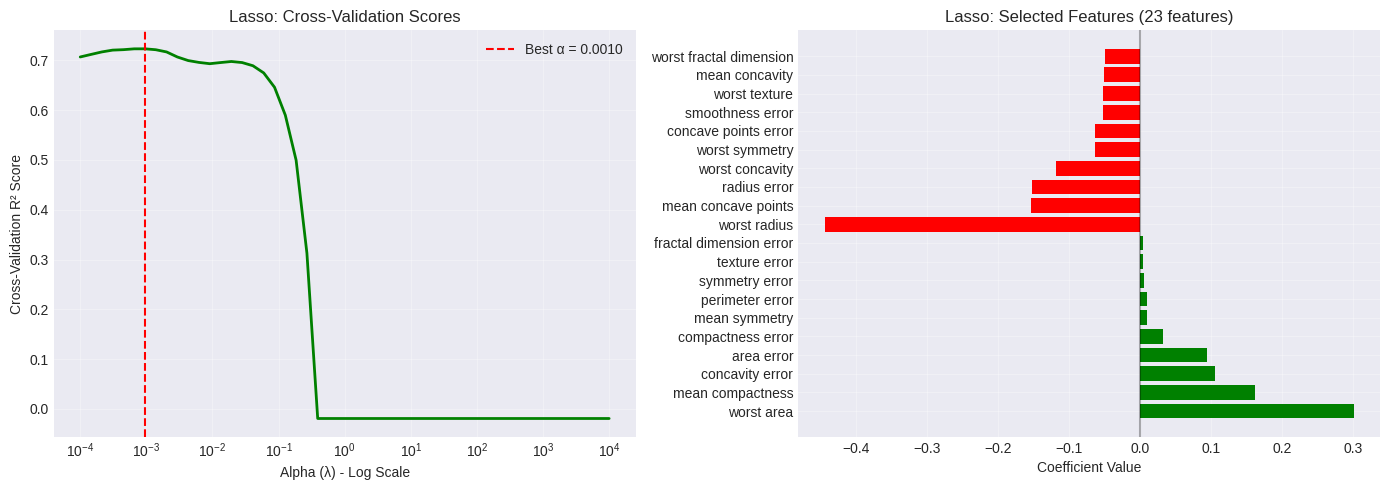

In [14]:
# Cell 9: Lasso Coefficient Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# 1. Lasso CV scores
ax = axes[0]
lasso_cv_scores = []
for alpha in alphas:
    lasso_temp = Lasso(alpha=alpha, max_iter =10000)
    scores = cross_val_score(lasso_temp,X_train_scaled,y_train,cv=5,scoring='r2')
    lasso_cv_scores.append(scores.mean())

ax.semilogx(alphas, lasso_cv_scores, 'g-', linewidth=2)
ax.axvline(best_lasso_alpha, color='red', linestyle='--', 
           label=f'Best α = {best_lasso_alpha:.4f}')
ax.set_xlabel('Alpha (λ) - Log Scale')
ax.set_ylabel('Cross-Validation R² Score')
ax.set_title('Lasso: Cross-Validation Scores')
ax.legend()
ax.grid(True, alpha=0.3)

#2. Lasso coefficients (showing sparsity)
ax = axes[1]
coeffs_lasso = pd.DataFrame({
    'Feature': data.feature_names,
    'Coefficient': lasso.coef_
})

coeffs_lasso = coeffs_lasso[np.abs(coeffs_lasso['Coefficient']) > 1e-10]
top_coeffs = coeffs_lasso.nlargest(10, 'Coefficient')
bottom_coeffs = coeffs_lasso.nsmallest(10, 'Coefficient')
top_bottom = pd.concat([top_coeffs, bottom_coeffs])

colors = ['green' if c > 0 else 'red' for c in top_bottom['Coefficient']]
ax.barh(top_bottom['Feature'], top_bottom['Coefficient'], color=colors)
ax.set_xlabel('Coefficient Value')
ax.set_title(f'Lasso: Selected Features ({len(coeffs_lasso)} features)')
ax.axvline(0, color='black', linestyle='-', alpha=0.3)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Model Training - ElasticNet with Grid Search


In [19]:
# Cell 10: ElasticNet Grid Search
print("="*60)
print("ELASTICNET REGRESSION")
print("="*60)
print("Performing Grid Search...")

# Define parameter grid
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 0.5, 1.0, 2.0],
    'l1_ratio': [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
}


elastic = ElasticNet(random_state = 42, max_iter=10000)

# Grid search with cross-validation
grid_search = GridSearchCV(
    elastic,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs = -1,
    verbose=0
)
grid_search.fit(X_train_scaled,y_train)

best_elastic = grid_search.best_estimator_
best_params = grid_search.best_params_

print(f"\nBest parameters found:")
print(f"  Alpha (α): {best_params['alpha']}")
print(f"  l1_ratio: {best_params['l1_ratio']}")
print(f"  Best CV R² Score: {grid_search.best_score_:.4f}")

# Train final ElasticNet model
elastic.fit(X_train_scaled,y_train)

# Predictions
elastic_train_pred = elastic.predict(X_train_scaled)
elastic_test_pred = elastic.predict(X_test_scaled)

# Metrics
elastic_train_r2 = r2_score(y_train, elastic_train_pred)
elastic_test_r2 = r2_score(y_test, elastic_test_pred)
elastic_test_mse = mean_squared_error(y_test, elastic_test_pred)
elastic_test_rmse = np.sqrt(elastic_test_mse)
elastic_test_mae = mean_absolute_error(y_test, elastic_test_pred)

print(f"\nTraining R²: {elastic_train_r2:.4f}")
print(f"Test R²: {elastic_test_r2:.4f}")
print(f"Test MSE: {elastic_test_mse:.4f}")
print(f"Test RMSE: {elastic_test_rmse:.4f}")
print(f"Test MAE: {elastic_test_mae:.4f}")
print(f"\nNumber of zero coefficients: {np.sum(np.abs(elastic.coef_) < 1e-10)}")
print(f"Features selected: {np.sum(np.abs(elastic.coef_) > 1e-10)} out of {len(elastic.coef_)}")

ELASTICNET REGRESSION
Performing Grid Search...

Best parameters found:
  Alpha (α): 0.001
  l1_ratio: 0.9
  Best CV R² Score: 0.7235

Training R²: 0.0000
Test R²: -0.0001
Test MSE: 0.2350
Test RMSE: 0.4847
Test MAE: 0.4684

Number of zero coefficients: 30
Features selected: 0 out of 30


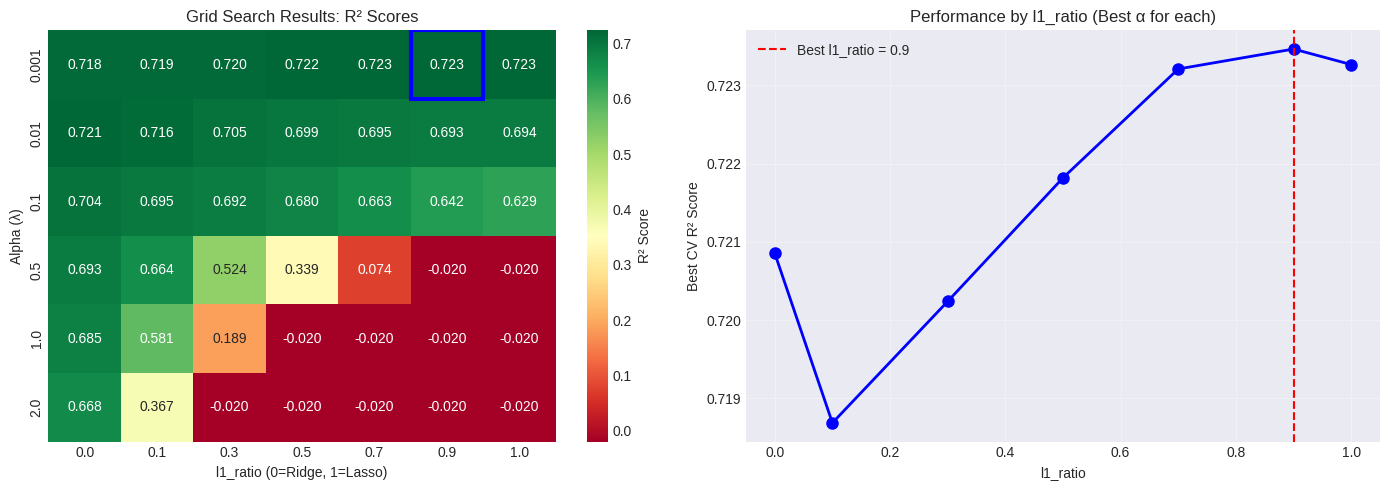

In [23]:
# Cell 11: Grid Search Results Visualization
results = pd.DataFrame(grid_search.cv_results_)

# Create Heatmap of grid search results
fig, axes = plt.subplots(1,2, figsize = (14,5))

# 1. Heatmap of CV scores
ax = axes[0]
pivot = results.pivot_table(
    values='mean_test_score',
    index='param_alpha',
    columns='param_l1_ratio'
)

sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', 
            ax=ax, cbar_kws={'label': 'R² Score'})
ax.set_title('Grid Search Results: R² Scores')
ax.set_xlabel('l1_ratio (0=Ridge, 1=Lasso)')
ax.set_ylabel('Alpha (λ)')

# Highlight best parameters
best_alpha_idx = pivot.index.get_loc(best_params['alpha'])
best_l1_idx = pivot.columns.get_loc(best_params['l1_ratio'])
ax.add_patch(plt.Rectangle((best_l1_idx, best_alpha_idx), 1, 1, 
                          fill=False, edgecolor='blue', linewidth=3))

                  # 2. Performance by l1_ratio
ax = axes[1]
l1_ratios = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
scores_by_l1 = []

for l1 in l1_ratios:
    mask = results['param_l1_ratio'] == l1
    best_score = results[mask]['mean_test_score'].max()
    scores_by_l1.append(best_score)

ax.plot(l1_ratios, scores_by_l1, 'bo-', linewidth=2, markersize=8)
ax.axvline(best_params['l1_ratio'], color='red', linestyle='--', 
           label=f'Best l1_ratio = {best_params["l1_ratio"]:.1f}')
ax.set_xlabel('l1_ratio')
ax.set_ylabel('Best CV R² Score')
ax.set_title('Performance by l1_ratio (Best α for each)')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()        

### 6. Model Comparison


In [24]:
# Cell 12: Comprehensive Model Comparison
print("="*60)
print("MODEL COMPARISON")
print("="*60)

# Create comparison DataFrame
comparison = pd.DataFrame({
    'Metric': ['R² (Train)', 'R² (Test)', 'MSE', 'RMSE', 'MAE', 'Zero Coeffs', 'Features Used'],
    'Ridge': [ridge_train_r2, ridge_test_r2, ridge_test_mse, 
              ridge_test_rmse, ridge_test_mae,
              np.sum(np.abs(ridge.coef_) < 1e-10),
              np.sum(np.abs(ridge.coef_) > 1e-10)],
    'Lasso': [lasso_train_r2, lasso_test_r2, lasso_test_mse,
              lasso_test_rmse, lasso_test_mae,
              np.sum(np.abs(lasso.coef_) < 1e-10),
              np.sum(np.abs(lasso.coef_) > 1e-10)],
    'ElasticNet': [elastic_train_r2, elastic_test_r2, elastic_test_mse,
                   elastic_test_rmse, elastic_test_mae,
                   np.sum(np.abs(elastic.coef_) < 1e-10),
                   np.sum(np.abs(elastic.coef_) > 1e-10)]
})

print(comparison.to_string(index=False))

# Performance summary
print("\n" + "="*60)
print("PERFORMANCE SUMMARY")
print("="*60)

best_model = comparison.columns[1:][comparison.loc[1, comparison.columns[1:]].argmax()]
best_r2 = comparison.loc[1, best_model]

print(f"Best performing model: {best_model}")
print(f"Best test R² score: {best_r2:.4f}")
print(f"ElasticNet l1_ratio: {best_params['l1_ratio']:.2f}")
print(f"(0 = Pure Ridge, 1 = Pure Lasso)")

MODEL COMPARISON
       Metric     Ridge     Lasso  ElasticNet
   R² (Train)  0.775336  0.774679    0.000000
    R² (Test)  0.739370  0.751436   -0.000141
          MSE  0.061227  0.058392    0.234952
         RMSE  0.247441  0.241645    0.484718
          MAE  0.195699  0.191779    0.468421
  Zero Coeffs  0.000000  7.000000   30.000000
Features Used 30.000000 23.000000    0.000000

PERFORMANCE SUMMARY
Best performing model: Lasso
Best test R² score: 0.7514
ElasticNet l1_ratio: 0.90
(0 = Pure Ridge, 1 = Pure Lasso)


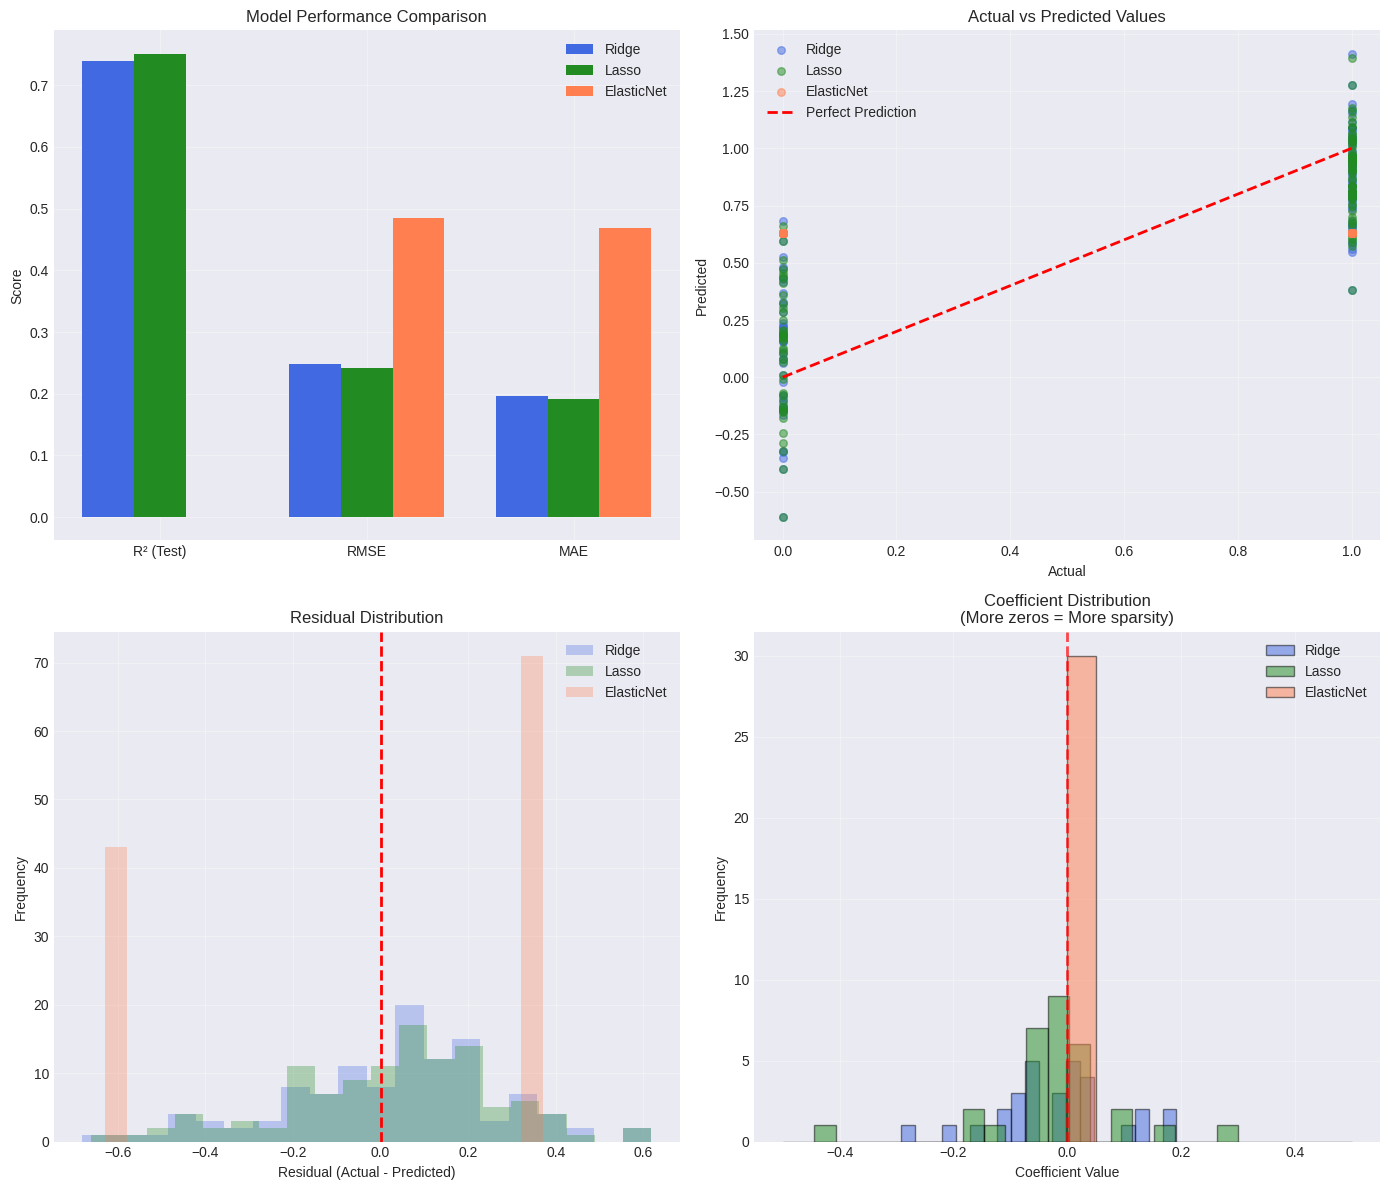

In [25]:
# Cell 13: Model Performance Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Performance comparison bar chart
ax = axes[0, 0]
metrics = ['R² (Test)', 'RMSE', 'MAE']
ridge_vals = [ridge_test_r2, ridge_test_rmse, ridge_test_mae]
lasso_vals = [lasso_test_r2, lasso_test_rmse, lasso_test_mae]
elastic_vals = [elastic_test_r2, elastic_test_rmse, elastic_test_mae]

x = np.arange(len(metrics))
width = 0.25

ax.bar(x - width, ridge_vals, width, label='Ridge', color='royalblue')
ax.bar(x, lasso_vals, width, label='Lasso', color='forestgreen')
ax.bar(x + width, elastic_vals, width, label='ElasticNet', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Actual vs Predicted for all models
ax = axes[0, 1]
ax.scatter(y_test, ridge_test_pred, alpha=0.5, label='Ridge', color='royalblue', s=30)
ax.scatter(y_test, lasso_test_pred, alpha=0.5, label='Lasso', color='forestgreen', s=30)
ax.scatter(y_test, elastic_test_pred, alpha=0.5, label='ElasticNet', color='coral', s=30)
ax.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect Prediction')
ax.set_xlabel('Actual')
ax.set_ylabel('Predicted')
ax.set_title('Actual vs Predicted Values')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Residuals distribution
ax = axes[1, 0]
ridge_residuals = y_test - ridge_test_pred
lasso_residuals = y_test - lasso_test_pred
elastic_residuals = y_test - elastic_test_pred

ax.hist(ridge_residuals, bins=20, alpha=0.3, label='Ridge', color='royalblue')
ax.hist(lasso_residuals, bins=20, alpha=0.3, label='Lasso', color='forestgreen')
ax.hist(elastic_residuals, bins=20, alpha=0.3, label='ElasticNet', color='coral')
ax.axvline(0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Residual (Actual - Predicted)')
ax.set_ylabel('Frequency')
ax.set_title('Residual Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Coefficient distribution (sparsity comparison)
ax = axes[1, 1]
ax.hist(ridge.coef_, bins=20, alpha=0.5, label='Ridge', color='royalblue', edgecolor='black')
ax.hist(lasso.coef_, bins=20, alpha=0.5, label='Lasso', color='forestgreen', edgecolor='black')
ax.hist(elastic.coef_, bins=20, alpha=0.5, label='ElasticNet', color='coral', edgecolor='black')
ax.axvline(0, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax.set_xlabel('Coefficient Value')
ax.set_ylabel('Frequency')
ax.set_title('Coefficient Distribution\n(More zeros = More sparsity)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 7. Feature Importance Analysis


In [26]:
# Cell 14: Feature Importance Comparison
print("="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Create comparison DataFrame
feature_importance = pd.DataFrame({
    'Feature': data.feature_names,
    'Ridge': ridge.coef_,
    'Lasso': lasso.coef_,
    'ElasticNet': elastic.coef_
})

# Calculate absolute importance
feature_importance['Ridge_Abs'] = np.abs(feature_importance['Ridge'])
feature_importance['Lasso_Abs'] = np.abs(feature_importance['Lasso'])
feature_importance['ElasticNet_Abs'] = np.abs(feature_importance['ElasticNet'])

# Top features for ElasticNet
top_elastic = feature_importance.nlargest(10, 'ElasticNet_Abs')

print("\nTop 10 Most Important Features (ElasticNet):")
print(top_elastic[['Feature', 'Ridge', 'Lasso', 'ElasticNet']].to_string(index=False))

# Features selected by each model
print("\n" + "="*60)
print("FEATURE SELECTION COMPARISON")
print("="*60)

ridge_selected = set(feature_importance[np.abs(feature_importance['Ridge']) > 1e-10]['Feature'])
lasso_selected = set(feature_importance[np.abs(feature_importance['Lasso']) > 1e-10]['Feature'])
elastic_selected = set(feature_importance[np.abs(feature_importance['ElasticNet']) > 1e-10]['Feature'])

print(f"Ridge selected: {len(ridge_selected)} features (all)")
print(f"Lasso selected: {len(lasso_selected)} features")
print(f"ElasticNet selected: {len(elastic_selected)} features")

# Overlap analysis
print(f"\nFeatures selected by ALL models: {len(ridge_selected & lasso_selected & elastic_selected)}")
print(f"Features only in Lasso: {len(lasso_selected - ridge_selected - elastic_selected)}")
print(f"Features only in ElasticNet: {len(elastic_selected - ridge_selected - lasso_selected)}")

FEATURE IMPORTANCE ANALYSIS

Top 10 Most Important Features (ElasticNet):
               Feature     Ridge     Lasso  ElasticNet
           mean radius -0.099074 -0.000000         0.0
          mean texture -0.013063 -0.020453         0.0
        mean perimeter -0.065933 -0.000000         0.0
             mean area  0.099138  0.000000         0.0
       mean smoothness  0.007042  0.000000         0.0
      mean compactness  0.189062  0.162288         0.0
        mean concavity -0.077324 -0.049856         0.0
   mean concave points -0.155215 -0.152696         0.0
         mean symmetry  0.018189  0.010568         0.0
mean fractal dimension -0.011274 -0.000000         0.0

FEATURE SELECTION COMPARISON
Ridge selected: 30 features (all)
Lasso selected: 23 features
ElasticNet selected: 0 features

Features selected by ALL models: 0
Features only in Lasso: 0
Features only in ElasticNet: 0


In [7]:
import numpy as np

# Given values
Z = 1.224744871391589
y_centered = np.array([-2, 0, 2])
beta1_new = 4.619

# Calculate ρ₁
print("="*50)
print("ρ₁ CALCULATION")
print("="*50)

rho1 = (-Z)*(-2) + 0*0 + Z*2
print(f"ρ₁ = (-{Z:.3f})(-2) + 0 + ({Z:.3f})(2)")
print(f"   = {(-Z)*(-2):.3f} + 0 + {Z*2:.3f}")
print(f"   = {rho1:.3f}")
print(f"✅ ρ₁ = {rho1:.3f}")

# Calculate β₁
print("\n" + "="*50)
print("β₁ CALCULATION")
print("="*50)

lambda_l1 = 0.05
soft_threshold = rho1 - lambda_l1
beta1 = soft_threshold / 1.05

print(f"S(ρ₁, {lambda_l1}) = {rho1} - {lambda_l1} = {soft_threshold:.3f}")
print(f"β₁ = {soft_threshold:.3f} / 1.05 = {beta1:.3f}")
print(f"✅ β₁ = {beta1:.3f}")

# Calculate ρ₂
print("\n" + "="*50)
print("ρ₂ CALCULATION")
print("="*50)

# For point 1
term1_1 = -Z
term1_2 = -2
term1_3 = term1_1 * beta1
term1_4 = term1_2 - term1_3
term1_5 = (-Z) * term1_4

print(f"Point 1:")
print(f"  y₁_centered - Z₁₁*β₁ = -2 - ({-Z:.3f}*{beta1:.3f})")
print(f"                        = -2 - ({term1_3:.3f})")
print(f"                        = {term1_4:.3f}")
print(f"  Z₁₂ * (...) = {-Z:.3f} * {term1_4:.3f} = {term1_5:.3f}")

# Point 3
term3_1 = Z
term3_2 = 2
term3_3 = term3_1 * beta1
term3_4 = term3_2 - term3_3
term3_5 = Z * term3_4

print(f"\nPoint 3:")
print(f"  y₃_centered - Z₃₁*β₁ = 2 - ({Z:.3f}*{beta1:.3f})")
print(f"                        = 2 - ({term3_3:.3f})")
print(f"                        = {term3_4:.3f}")
print(f"  Z₃₂ * (...) = {Z:.3f} * {term3_4:.3f} = {term3_5:.3f}")

rho2 = term1_5 + 0 + term3_5
print(f"\nρ₂ = {term1_5:.3f} + 0 + {term3_5:.3f} = {rho2:.3f}")
print(f"✅ ρ₂ = {rho2:.3f}")

# Calculate β₂
print("\n" + "="*50)
print("β₂ CALCULATION")
print("="*50)

soft_threshold2 = rho2 + lambda_l1  # Since rho2 is negative
beta2 = soft_threshold2 / 1.05

print(f"S({rho2:.3f}, {lambda_l1}) = {rho2} + {lambda_l1} = {soft_threshold2:.3f}")
print(f"β₂ = {soft_threshold2:.3f} / 1.05 = {beta2:.3f}")
print(f"✅ β₂ = {beta2:.3f}")

ρ₁ CALCULATION
ρ₁ = (-1.225)(-2) + 0 + (1.225)(2)
   = 2.449 + 0 + 2.449
   = 4.899
✅ ρ₁ = 4.899

β₁ CALCULATION
S(ρ₁, 0.05) = 4.898979485566356 - 0.05 = 4.849
β₁ = 4.849 / 1.05 = 4.618
✅ β₁ = 4.618

ρ₂ CALCULATION
Point 1:
  y₁_centered - Z₁₁*β₁ = -2 - (-1.225*4.618)
                        = -2 - (-5.656)
                        = 3.656
  Z₁₂ * (...) = -1.225 * 3.656 = -4.478

Point 3:
  y₃_centered - Z₃₁*β₁ = 2 - (1.225*4.618)
                        = 2 - (5.656)
                        = -3.656
  Z₃₂ * (...) = 1.225 * -3.656 = -4.478

ρ₂ = -4.478 + 0 + -4.478 = -8.955
✅ ρ₂ = -8.955

β₂ CALCULATION
S(-8.955, 0.05) = -8.955247616051802 + 0.05 = -8.905
β₂ = -8.905 / 1.05 = -8.481
✅ β₂ = -8.481
